In [1]:
import numpy as np
import pandas as pd
import scanpy as sc

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import fast_matrix_market as fmm
from sklearn.cluster import KMeans
import scanpy as sc
import scipy.io
import cupy as cp
from cuml.cluster import KMeans

# Some plotting aesthetics
%matplotlib inline

sns.set_style('ticks')
matplotlib.rcParams['figure.figsize'] = [4, 4]
matplotlib.rcParams['figure.dpi'] = 100

In [2]:
!hostname

ne1dg6-007.nygenome.org


In [3]:
import scanpy as sc
from cuml.decomposition import PCA
from cuml.cluster import KMeans
import cupy as cp
from scipy.sparse import csr_matrix
import numpy as np

### Generate Anndata object from gene count matrix and annotation file 

In [4]:
# Working directory 
WD="/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/EasySci2024/LeafletFA/"

# GE matrix - how did they combine reads across DT and RH reads? 
ge_matrix="/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/EasySci2024/EasySci-RNA-mouse-brain/GSM6538356_RNA_gene_count.txt.gz"

# Metadata 
metadata="/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/EasySci2024/EasySci-RNA-mouse-brain/GSM6538356_RNA_cell_annotation.csv.gz"
metadata = pd.read_csv(metadata)

# read cells file Cell_annotation.csv
cells = pd.read_csv('/gpfs/commons/groups/knowles_lab/data/sc/rockefeller_2022/Cell_annotation.csv')
cells["pair_code"] = range(1, len(cells) + 1)

# Gene annotations 
gene_annots = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/EasySci2024/EasySci-RNA-mouse-brain/GSM6538356_RNA_gene_annotation.csv.gz"
gene_annots = pd.read_csv(gene_annots)

In [5]:
# make a dataframe for sample names and whether they are DT or RH 
samps_prime = cells[["Cell_random_hexamer", "pair_code"]].copy()
samps_prime["primer"] = "RH"
samps_prime.drop_duplicates(inplace=True)

# rename first column to "sample"
samps_prime = samps_prime.rename(columns={"Cell_random_hexamer": "sample"})
samps_prime_RH = samps_prime 

# now do the same for DT 
samps_prime = cells[["Cell_shortDT", "pair_code"]].copy()
samps_prime["primer"] = "DT"
samps_prime.drop_duplicates(inplace=True)

# rename first column to "sample"
samps_prime = samps_prime.rename(columns={"Cell_shortDT": "sample"})
samps_prime_DT = samps_prime

In [6]:
samps_prime = pd.concat([samps_prime_RH, samps_prime_DT])
# merge metadata with samps_prime on "sample"
metadata = metadata.merge(samps_prime, on="sample")
metadata.primer.value_counts() # this isn't actually meaningful though, seems for the metadata file they just chose one of the barcodes RH or RT to label the cell but the signal should be across both 

primer
RH    737654
DT    731457
Name: count, dtype: int64

### Make an anndata object using gene expression 

In [7]:
# Replace 'data.mtx' with the path to your MatrixMarket file
matrix = fmm.mmread(ge_matrix)
# transpose matrix 
matrix = matrix.T
# convert COO to CSR or CSC sparse matrix
matrix = matrix.tocsr()
adata = sc.AnnData(X=matrix)
# now add gene_annots as gene annotations in the anndata object
adata.var = gene_annots
# create anndata object from gene_matrix and metadata
adata.obs = metadata
print("Done creating anndata object")

Done creating anndata object


### Split anndata object into one for RH and one for DT cell files

In [8]:
# Split AnnData object based on 'primer' column
RH_anndata = adata[adata.obs["primer"] == "RH"].copy()
DT_anndata = adata[adata.obs["primer"] == "DT"].copy()

/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [9]:
RH_anndata, DT_anndata

(AnnData object with n_obs × n_vars = 737654 × 55416
     obs: 'sample', 'UMI_count', 'Gene_count', 'PCR_sample_name', 'Ligation_barcode', 'RT_barcode', 'umap_1', 'umap_2', 'Louvain_cluster', 'Type', 'Sex', 'Replicate_ID', 'Main_cluster_name', 'Subcluster_id', 'Subcluster_umap_1', 'Subcluster_umap_2', 'Sub_cluster_num', 'pair_code', 'primer'
     var: 'gene_id', 'gene_type', 'gene_short_name',
 AnnData object with n_obs × n_vars = 731457 × 55416
     obs: 'sample', 'UMI_count', 'Gene_count', 'PCR_sample_name', 'Ligation_barcode', 'RT_barcode', 'umap_1', 'umap_2', 'Louvain_cluster', 'Type', 'Sex', 'Replicate_ID', 'Main_cluster_name', 'Subcluster_id', 'Subcluster_umap_1', 'Subcluster_umap_2', 'Sub_cluster_num', 'pair_code', 'primer'
     var: 'gene_id', 'gene_type', 'gene_short_name')

In [10]:
def preprocess_and_with_rapids(adata, min_genes=200, min_cells=3, 
                               max_counts=None):
    """
    Preprocess AnnData with QC filtering and RAPIDS acceleration
    """
    # Store raw counts
    adata.layers["counts"] = adata.X.copy()
    
    # Calculate QC metrics
    sc.pp.calculate_qc_metrics(adata, 
                             percent_top=None, 
                             log1p=False, 
                             inplace=True)
    
    # Filter cells
    cell_mask = (adata.obs.n_genes_by_counts > min_genes)
    if max_counts:
        cell_mask &= (adata.obs.total_counts < max_counts)

    adata = adata[cell_mask]
    
    # Filter genes
    gene_mask = (adata.var.n_cells_by_counts > min_cells)
    adata = adata[:, gene_mask]
    
    print(f"After QC: {adata.shape[0]} cells and {adata.shape[1]} genes")
    
    # Store unfiltered matrix
    adata.layers["raw"] = adata.X.copy()
    
    # Normalize and transform
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)
    
    # Find variable genes but keep all
    sc.pp.highly_variable_genes(adata, n_top_genes=2000)
    adata.var["is_variable"] = adata.var["highly_variable"]
    
    # RAPIDS PCA on variable genes only
    var_idx = adata.var["highly_variable"]
    if isinstance(adata.X, csr_matrix):
        gpu_X = cp.sparse.csr_matrix(adata.X[:, var_idx].astype(np.float32))
    else:
        gpu_X = cp.asarray(adata.X[:, var_idx], dtype=cp.float32)
    
    # PCA
    pca_model = PCA(n_components=50, random_state=42)
    pca_result = pca_model.fit_transform(gpu_X)
    adata.obsm["X_pca"] = cp.asnumpy(pca_result)
    print("PCA completed and converted to NumPy!")
    
    # Neighbors and UMAP
    sc.pp.neighbors(adata, n_neighbors=15, use_rep="X_pca")
    print(f"Done computing neighbors!")

    sc.tl.umap(adata, method="rapids")
    print(f"Done with UMAP!")

    return adata

In [16]:
def cluster_with_rapids(adata, target_metacell_size=300):

    # Cluster using RAPIDS k-means
    n_clusters = adata.shape[0] // target_metacell_size  # Determine the number of clusters
    print(f"Now running KMeans with {n_clusters} clusters...")
    kmeans_model = KMeans(n_clusters=n_clusters, random_state=42)
    
    # Convert k-means result from cupy to numpy for compatibility with AnnData
    adata.obs["kmeans_cluster"] = kmeans_model.fit_predict(cp.asarray(adata.obsm["X_pca"])).get()
    print(f"Done obtaining cluster labels for each cell in the dataset!")
    print(f"The final number of clusters is {adata.obs['kmeans_cluster'].nunique()}")
    return adata

In [12]:
RH_anndata = preprocess_and_with_rapids(RH_anndata)
DT_anndata = preprocess_and_with_rapids(DT_anndata)

After QC: 737654 cells and 43762 genes


/scratch/ipykernel_3744723/3137820833.py:29: ImplicitModificationWarning: Setting element `.layers['raw']` of view, initializing view as actual.
  adata.layers["raw"] = adata.X.copy()


PCA completed and converted to NumPy!
Done computing neighbors!


/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/scanpy/tools/_umap.py:233: FutureWarning: `method='rapids'` is deprecated. Use `rapids_singlecell.tl.louvain` instead.
  warnings.warn(msg, FutureWarning)


Done with UMAP!
After QC: 731457 cells and 43639 genes


/scratch/ipykernel_3744723/3137820833.py:29: ImplicitModificationWarning: Setting element `.layers['raw']` of view, initializing view as actual.
  adata.layers["raw"] = adata.X.copy()


PCA completed and converted to NumPy!
Done computing neighbors!


/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/scanpy/tools/_umap.py:233: FutureWarning: `method='rapids'` is deprecated. Use `rapids_singlecell.tl.louvain` instead.
  warnings.warn(msg, FutureWarning)


Done with UMAP!


In [17]:
RH_anndata = cluster_with_rapids(RH_anndata)
DT_anndata = cluster_with_rapids(DT_anndata)

Now running KMeans with 2458 clusters...
Done obtaining cluster labels for each cell in the dataset!
The final number of clusters is 2458
Now running KMeans with 2438 clusters...
Done obtaining cluster labels for each cell in the dataset!
The final number of clusters is 2438


In [18]:
# should also consider age / disease context 
# clean up columns in metadata so can make clean cluster names that include cell type annotation (Main_cluster_name) + kmeans cluster number + mouse context (Type)
# make a new columns in .obs combining kmeans_cluster with Main_cluster_name 
RH_anndata.obs["Main_cluster_name"] = RH_anndata.obs["Main_cluster_name"].astype(str)
DT_anndata.obs["Main_cluster_name"] = DT_anndata.obs["Main_cluster_name"].astype(str)

RH_anndata.obs["Type"] = RH_anndata.obs["Type"].astype(str)
DT_anndata.obs["Type"] = DT_anndata.obs["Type"].astype(str)

# if any "/" are present in "Type" column, replace with "_"
RH_anndata.obs["Type"] = RH_anndata.obs["Type"].str.replace("/", "_")
DT_anndata.obs["Type"] = DT_anndata.obs["Type"].str.replace("/", "_")

RH_anndata.obs["Main_cluster_name"] = RH_anndata.obs["Main_cluster_name"].str.replace(" ", "_")
DT_anndata.obs["Main_cluster_name"] = DT_anndata.obs["Main_cluster_name"].str.replace(" ", "_")

RH_anndata.obs["Main_cluster_name_wkmeans"] = RH_anndata.obs["Main_cluster_name"] + "_" + RH_anndata.obs["Type"] + "_" + RH_anndata.obs["kmeans_cluster"].astype(str)
DT_anndata.obs["Main_cluster_name_wkmeans"] = DT_anndata.obs["Main_cluster_name"] + "_" + DT_anndata.obs["Type"] + "_" + DT_anndata.obs["kmeans_cluster"].astype(str)

In [19]:
# Summary of clusters
summ_RH = pd.DataFrame(RH_anndata.obs.Main_cluster_name_wkmeans.value_counts())
summ_RH = summ_RH[summ_RH["count"] >= 20]
RH_anndata = RH_anndata[RH_anndata.obs.Main_cluster_name_wkmeans.isin(summ_RH.index)]

summ_DT = pd.DataFrame(DT_anndata.obs.Main_cluster_name_wkmeans.value_counts())
summ_DT = summ_DT[summ_DT["count"] >= 20]
DT_anndata = DT_anndata[DT_anndata.obs.Main_cluster_name_wkmeans.isin(summ_DT.index)]

In [20]:
print(f"The final number of cells in the RH dataset is {RH_anndata.shape[0]}")
print(f"The final number of cells in the DT dataset is {DT_anndata.shape[0]}")
print(f"The final number of clusters in the RH dataset is {RH_anndata.obs['Main_cluster_name_wkmeans'].nunique()}")
print(f"The final number of clusters in the DT dataset is {DT_anndata.obs['Main_cluster_name_wkmeans'].nunique()}")

The final number of cells in the RH dataset is 657449
The final number of cells in the DT dataset is 652310
The final number of clusters in the RH dataset is 10014
The final number of clusters in the DT dataset is 9723


In [30]:
RH_anndata.obs.Main_cluster_name_wkmeans.value_counts().sample()

Main_cluster_name_wkmeans
Astrocytes_APOE4_TREM2_1704    56
Name: count, dtype: int64

/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_co

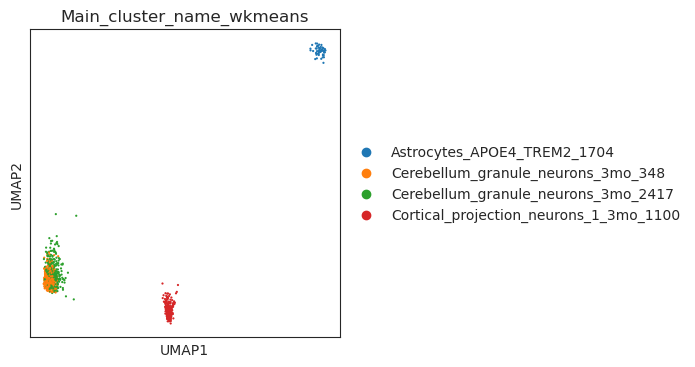

In [31]:
# Plot UMAP but just for two random clusters to see if they are separated 
subset_clust = RH_anndata[RH_anndata.obs.Main_cluster_name_wkmeans.isin(["Cerebellum_granule_neurons_3mo_2417", "Cerebellum_granule_neurons_3mo_348", "Cortical_projection_neurons_1_3mo_1100", "Astrocytes_APOE4_TREM2_1704"])]
sc.pl.umap(subset_clust, color="Main_cluster_name_wkmeans", ncols=1, cmap="tab20", s=10)

### Save dataframes containing cell mappings from new metacell to original individal cell BAM id

In [32]:
save_DT_cells = DT_anndata.obs[["sample", "Type", "primer", "Main_cluster_name", "Main_cluster_name_wkmeans"]]
# make new column called "cell_BAM_file_name" that is the same as "sample" but with .DT.bam at the end 
save_DT_cells["cell_BAM_file_name"] = save_DT_cells["sample"] + ".DT.bam"
save_DT_cells = save_DT_cells.drop_duplicates()
save_DT_cells.to_csv(WD + "DT_cells.csv", index=False)

/scratch/ipykernel_3744723/2715388844.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  save_DT_cells["cell_BAM_file_name"] = save_DT_cells["sample"] + ".DT.bam"


In [33]:
# now do the same for RH
save_RH_cells = RH_anndata.obs[["sample", "Type", "primer", "Main_cluster_name", "Main_cluster_name_wkmeans"]]
# make new column called "cell_BAM_file_name" that is the same as "sample" but with .DT.bam at the end
save_RH_cells["cell_BAM_file_name"] = save_RH_cells["sample"] + ".RH.bam"
save_RH_cells = save_RH_cells.drop_duplicates()
save_RH_cells.to_csv(WD + "RH_cells.csv", index=False)

/scratch/ipykernel_3744723/1413428341.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  save_RH_cells["cell_BAM_file_name"] = save_RH_cells["sample"] + ".RH.bam"


In [34]:
# Save also versions for anndata object removing individual cell ids and just keeping metacell info
RH_anndata_meta = save_RH_cells[["Main_cluster_name", "Main_cluster_name_wkmeans", "Type", "primer"]].drop_duplicates()
DT_anndata_meta = save_DT_cells[["Main_cluster_name", "Main_cluster_name_wkmeans", "Type", "primer"]].drop_duplicates()

# save as csv
RH_anndata_meta.to_csv(WD + "RH_anndata_meta.tsv", index=False)
DT_anndata_meta.to_csv(WD + "DT_anndata_meta.tsv", index=False)

In [35]:
# print number of unique clusters in each dataset 
print("Number of unique clusters in RH data: ", RH_anndata.obs.Main_cluster_name_wkmeans.nunique())
print("Number of unique clusters in DT data: ", DT_anndata.obs.Main_cluster_name_wkmeans.nunique())

Number of unique clusters in RH data:  10014
Number of unique clusters in DT data:  9723


# Save the Anndata objects to file 

In [36]:
RH_anndata

View of AnnData object with n_obs × n_vars = 657449 × 43762
    obs: 'sample', 'UMI_count', 'Gene_count', 'PCR_sample_name', 'Ligation_barcode', 'RT_barcode', 'umap_1', 'umap_2', 'Louvain_cluster', 'Type', 'Sex', 'Replicate_ID', 'Main_cluster_name', 'Subcluster_id', 'Subcluster_umap_1', 'Subcluster_umap_2', 'Sub_cluster_num', 'pair_code', 'primer', 'n_genes_by_counts', 'total_counts', 'kmeans_cluster', 'Main_cluster_name_wkmeans'
    var: 'gene_id', 'gene_type', 'gene_short_name', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'is_variable'
    uns: 'log1p', 'hvg', 'neighbors', 'umap'
    obsm: 'X_pca', 'X_umap'
    layers: 'counts', 'raw'
    obsp: 'distances', 'connectivities'

In [37]:
RH_anndata.write(WD + "RH_anndata.h5ad", compression="lzf")

/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_co

In [38]:
DT_anndata.write(WD + "DT_anndata.h5ad", compression="lzf")

/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_co